# Detecção de outliers

Neste notebook vamos procurar outliers em um conjunto de dados reais de venda de diamantes. Os dados foram baixados de:

https://www.openml.org/d/42225

Cada linha é um diamante vendido. As colunas são:

- `carat`: peso, em quilates (1 quilate equivale a 0,2 grama)
- `cut`: qualidade do corte (Fair, Good, Very Good, Premium, Ideal)
- `color`: cor do diamante (J (pior) a D (melhor))
- `clarity`: clareza do diamante (I1 (pior), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (melhor))
- `depth`: altura da pedra em relação ao diâmetro, em porcentagem. $z / mean(x, y) = 2 * z / (x + y)$
- `table`: largura da face superior em relação ao diâmetro, em porcentagem
- `price`: preço de venda, em dólares
- `x`, `y`, `z`: comprimento, largura e altura, em milímetros

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/diamonds.csv")
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [2]:
df.shape

(53940, 10)

In [3]:
df.describe().round(2)

,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


- Tipicamente, a maioria dos valores possui carat < 2 e tamanho < 7. 
- Já vemos que há problema no valor mínimo de x, y e z, que é 0. 

## Regras de domínio

Vale checar o que o domínio já proíbe. Essa checagem não depende de nenhuma suposição sobre a distribuição dos dados.

Nesse dataset, nenhum valor numérico pode ser negativo ou zero:

In [4]:
df_num = df.select_dtypes(include='number')
for col in df_num.columns:
    n = (df[col] <= 0).sum()
    print(f"Coluna {col}: {n} valores <= 0")

Coluna carat: 0 valores <= 0
Coluna depth: 0 valores <= 0
Coluna table: 0 valores <= 0
Coluna price: 0 valores <= 0
Coluna x: 8 valores <= 0
Coluna y: 7 valores <= 0
Coluna z: 20 valores <= 0


In [6]:
# As linhas com alguma dimensão igual a zero
mask_zeros = (df[["x", "y", "z"]] == 0).any(axis=1)
df[mask_zeros].head()

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0


Ao invés de NA, foi utilizado 0 para indicar a ausência de valor. 

A descrição indica que $depth = 2 * z / (x + y)$:

In [7]:
depth = 2*df["z"] / (df["x"] + df["y"])
# Converte para porcentagem
depth = 100*depth
# Diferença entre os valores
diff = df["depth"] - depth
n_diff = (diff.abs() > 1.0).sum()
print(f"{n_diff} linhas em que depth != 2*z/(x+y)")

93 linhas em que depth != 2*z/(x+y)


In [8]:
df_temp = df.copy()
df_temp["depth_diff"] = diff
# Linhas com maior diferença de depth calculado e depth informado, excluindo linhas com dimensões iguais a zero
df_temp[~mask_zeros].sort_values("depth_diff", ascending=False).head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z,depth_diff
14635,1.07,Ideal,F,SI1,60.6,57.0,5909,6.62,6.67,1.07,44.497667
20694,1.53,Ideal,I,SI1,61.9,54.0,8971,7.43,7.50,1.53,41.404354
21654,1.41,Ideal,H,VS1,60.7,56.0,9752,7.31,7.22,1.41,41.291879
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06,34.836707
49189,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12,34.086874
47138,0.55,Very Good,E,VS2,61.0,59.0,1831,5.31,5.34,2.25,18.746479
39246,0.38,Ideal,E,VVS2,60.9,56.0,1068,4.71,4.68,2.06,17.023536
2941,1.00,Very Good,J,SI2,62.8,63.0,3293,6.26,6.19,3.19,11.555020
19502,1.57,Fair,H,VS1,67.3,66.0,8133,7.85,5.75,3.87,10.388235
33102,0.34,Good,E,VS2,57.0,61.0,816,6.65,4.61,2.64,10.108348


In [9]:
# Linhas duplicadas exatas
df.duplicated().sum()

np.int64(146)

## Detecção univariada

In [10]:
def zscore(x):
    """Distância até a média, em desvios-padrão."""
    return (x - x.mean()) / x.std()

def robust_zscore(x):
    """Distância até a mediana, em unidades de MAD."""
    median = x.median()
    mad = (x - median).abs().median()
    return 0.6745 * (x - median) / mad

def iqr_limits(x, factor=1.5):
    """Limites inferior e superior pela regra do intervalo interquartil."""
    q1, q3 = x.quantile([0.25, 0.75])
    return q1 - factor * (q3 - q1), q3 + factor * (q3 - q1)

def count_flagged(x):
    """Número de valores marcados por cada uma das três regras, utilizando limiares comuns."""
    lower, upper = iqr_limits(x)
    print(f"z-score:   {(zscore(x).abs() > 3).sum()}")
    print(f"z robusto: {(robust_zscore(x).abs() > 3.5).sum()}")
    print(f"IQR:       {((x < lower) | (x > upper)).sum()}")

### A coluna `y` (largura)

In [ ]:
count_flagged(df["y"])


Coluna x:
z-score:   43
z robusto: 9
IQR:       32

Coluna y:
z-score:   34
z robusto: 10
IQR:       29

Coluna z:
z-score:   55
z robusto: 24
IQR:       49


In [12]:
# Os maiores valores de y
df.nlargest(6, "y")

,carat,cut,color,clarity,depth,table,price,x,y,z
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06
49189,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17
25999,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24


- Na linha 24067 o valor de `y` é 58.90, que é exatamente o valor de `depth` da mesma linha.
- Na linha 49189 o valor de `y` é 31.80, enquanto `x=5.15`, `z=5.12` e `carat=0.51`. 
- É possível utilizar imputação para corrigir os valores.

### A coluna `price`

O preço é uma quantia que cresce de forma multiplicativa, o que naturalmente possui cauda longa e gera outliers:

In [16]:
count_flagged(df["price"])

z-score:   1206
z robusto: 4232
IQR:       3540


## Assimetria e transformação

In [17]:
df[["price"]].skew()

price    1.618395
dtype: float64

In [18]:
log_price = np.log(df["price"])
log_price.skew()

np.float64(0.11529585821715067)

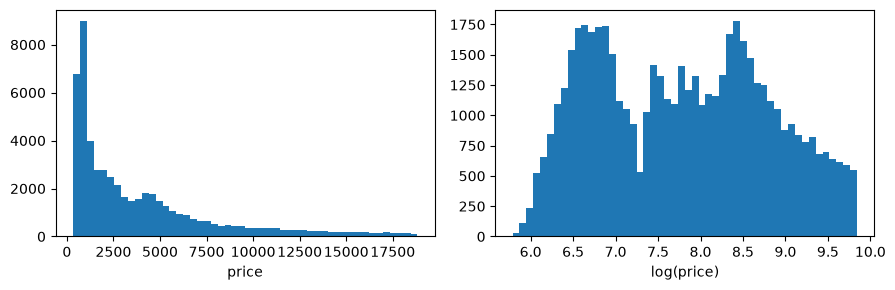

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist(df["price"], bins=50)
axes[0].set_xlabel("price")
axes[1].hist(log_price, bins=50)
axes[1].set_xlabel("log(price)")
fig.tight_layout()
plt.show()

In [20]:
count_flagged(log_price)

z-score:   0
z robusto: 0
IQR:       0


Na escala "natural" da grandeza, não há outliers!

## Os artefatos que a detecção univariada não encontra

(3.0, 10.0)

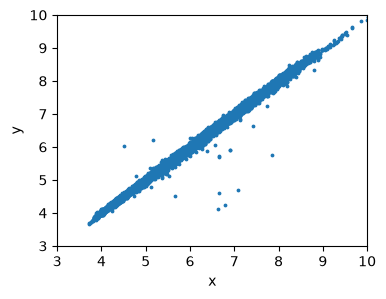

In [21]:
plt.scatter(df["x"], df["y"], s=3)
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(3, 10)
plt.ylim(3, 10)

A grande maioria das pedras é lapidada em formato redondo, mas algumas possuem dimensão x e y muito diferentes.

(2.0, 6.0)

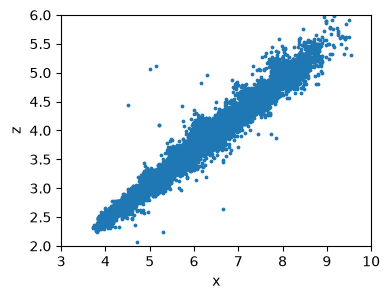

In [22]:
plt.scatter(df["x"], df["z"], s=3)
plt.xlabel("x")
plt.ylabel("z")
plt.xlim(3, 10)
plt.ylim(2, 6)

A grande maioria das pedras possui altura z relacionada com x e y, mas algumas possuem altura z muito diferente.

## Colunas derivadas do domínio

Diamantes de lapidação redonda são simétricos, então `x` e `y` devem ser quase iguais. E a densidade deve ser similar, porque todas as pedras são feitas do mesmo material.

In [23]:
df_sizes = df[["x", "y", "z"]]
# Ignoramos linhas com dimensão igual a 0 e com dimensão maior que 30 mm (erros identificados acima)
mask_correct = ((df_sizes > 0) & (df_sizes < 30)).all(axis=1)

ratio = (df["x"] / df["y"])[mask_correct]
density = (df["carat"] / (df["x"] * df["y"] * df["z"]))[mask_correct]

In [24]:
# O desvio padrão de ambas as quantias é pequeno em relação à média, então a maioria das pedras é simétrica e possui densidade similar.
print(ratio.describe().round(2))
print(density.describe().round(4))

count    53917.00
mean         1.00
std          0.01
min          0.75
25%          0.99
50%          1.00
75%          1.01
max          1.62
dtype: float64
count    53917.0000
mean         0.0061
std          0.0002
min          0.0028
25%          0.0060
50%          0.0061
75%          0.0062
max          0.0226
dtype: float64


In [25]:
flagged_density = robust_zscore(density).abs() > 10
flagged_ratio = robust_zscore(ratio).abs() > 10

print(f"densidade fora do padrão: {flagged_density.sum()}")
print(f"razão x/y fora do padrão: {flagged_ratio.sum()}")

densidade fora do padrão: 32
razão x/y fora do padrão: 13


In [26]:
# As linhas com a densidade mais estranha
df.loc[robust_zscore(density).nlargest(8).index]

,carat,cut,color,clarity,depth,table,price,x,y,z
14635,1.07,Ideal,F,SI1,60.6,57.0,5909,6.62,6.67,1.07
21654,1.41,Ideal,H,VS1,60.7,56.0,9752,7.31,7.22,1.41
20694,1.53,Ideal,I,SI1,61.9,54.0,8971,7.43,7.50,1.53
17826,1.51,Fair,H,VS2,65.6,56.0,7188,7.08,4.70,4.00
2274,1.22,Premium,J,SI2,62.6,59.0,3156,6.79,4.24,3.76
15235,1.12,Premium,H,VS1,61.6,58.0,6115,6.64,4.11,3.70
25849,2.00,Premium,G,SI1,59.0,62.0,14918,6.16,6.15,4.82
26495,2.06,Premium,H,SI2,60.0,60.0,16098,6.29,6.25,4.96


Usamos conhecimento de domínio para identificar situações anômalas. Vamos tentar encontrar os mesmos casos usando detecção de outliers multivariada.

In [27]:
# Guardamos as linhas suspeitas para usar como referência de comparação
suspects = sorted(set(density.index[flagged_density]) | set(ratio.index[flagged_ratio]))
len(suspects)

37

## Detecção multivariada

In [28]:
from sklearn.covariance import EmpiricalCovariance, MinCovDet
from sklearn.preprocessing import PowerTransformer

def get_worst(scores, k=50):
    """Retorna os índices das k linhas mais anômalas, de acordo com os scores fornecidos."""
    # Ordena em ordem decrescente de scores e extrai os índices dos k maiores
    ranking = np.argsort(scores)[::-1][:k]
    # Índices das k linhas mais anômalas
    return df.index[ranking]

def count_hits(scores, k=50):
    """Quantas linhas suspeitas estão entre as k mais anômalas."""
    hits = set(get_worst(scores, k)) & set(suspects)
    return len(hits)

X = df.select_dtypes(include='number')
X_yj = PowerTransformer().fit_transform(X)

estimators = [("clássico", EmpiricalCovariance()), ("MCD", MinCovDet(random_state=0))]

for data_name, data in [("dados crus", X), ("yeo-johnson", X_yj)]:
    for name, estimator in estimators:
        d2 = estimator.fit(data).mahalanobis(data)
        print(f"{data_name:>11} | {name:>8}: {count_hits(d2)} suspeitos entre os 50 mais anômalos")

 dados crus | clássico: 9 suspeitos entre os 50 mais anômalos
 dados crus |      MCD: 12 suspeitos entre os 50 mais anômalos
yeo-johnson | clássico: 21 suspeitos entre os 50 mais anômalos
yeo-johnson |      MCD: 18 suspeitos entre os 50 mais anômalos


- Nos dados crus o MCD encontra mais que o estimador clássico, pois a cauda longa da distribuição de `price` e possivelmente outras colunas distorcem a média e a matriz de covariância.
- Após a transformação, ambos os métodos melhoram e se tornam parecidos.

### Detecção com o `LocalOutlierFactor`

In [30]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20).fit(X_yj)
# quanto maior, mais anômalo
lof_score = -lof.negative_outlier_factor_          

print(f"LOF: {count_hits(lof_score)} suspeitos entre os 50 mais anômalos")

LOF: 20 suspeitos entre os 50 mais anômalos


## O que fazer com os outliers

In [31]:
df_clean = df.copy()

dims = ["x", "y", "z"]
df_clean[dims] = df_clean[dims].replace(0, np.nan)

suspects = get_worst(lof_score, 50)
df_clean["is_suspect"] = df_clean.index.isin(suspects)

## Novidade

Nem todo ponto distante é erro. Detecção de outliers pode ser utilizado para detectar **novidade**.

Suponha que a loja só tenha vendido pedras de até 3 quilates até hoje, e que chegue um lote
com pedras maiores.

In [33]:
# Seleção de treinamento e teste
mask = df["carat"] <= 3
X_history = X[mask]
X_new = X[~mask]

# Transformação aprendida no histórico
pt_history = PowerTransformer().fit(X_history)
X_history = pt_history.transform(X_history)
print(f"histórico: {len(X_history)} pedras")

histórico: 53908 pedras


In [34]:
# Novas pedras
X_new = pt_history.transform(X_new)

# novelty=True cria a classe em modo de detecção de novidade, permitindo que o modelo seja treinado em um conjunto e depois aplicado a outro.
detector = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(X_history)
# +1 para normal, -1 para anômalo
labels = detector.predict(X_new)                

print(f"marcados como anômalos no lote novo: {(labels == -1).sum()} de {len(X_new)}")

marcados como anômalos no lote novo: 29 de 32
